## Business Understanding

Like most telecommunication companies, customer retention remains a critical challenge for SyriaTel. This is because as acquiring new customers is often more expensive than keeping existing ones. SyriaTel is experiencing customer churn where users discontinue their service. Identifying the patterns and factors that drive churn can help the company take proactive measures to reduce customer loss, enhance loyalty, and increase revenue.

## Problem Statement
By leveraging historical customer data, we aim to uncover key factors that predict churn

## Objectives
**Classification**
- Build a predictive model that accurately identifies customers at risk of churning
- Optimize model performance using feature engineering and tuning.

## Data understanding


In [3]:
#Load the requisite libraries
#Load the data
#Preview the data

import pandas as pd
import seaborn as sns #To Facilitate visualizations
import matplotlib.pyplot as plt #To facilitate visualizations
import numpy as np #To facilitate mathematical calculations
from scipy.stats import skew, kurtosis
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from scipy.stats import linregress
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import itertools
!pip install xgboost
!pip install catboost

df= pd.read_csv('data/churn.csv')
df.head()


RuntimeError: module compiled against API version 0xe but this version of numpy is 0xd

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

The dataset has a mix of categorical data and numerical data. These can be summarized as follows:
**Customer Information**
* state - The U.S. state where the customer resides.
* account length - The number of days the customer has had an active account with SyriaTel.
* area code - The area code of the customer's phone number.
* phone number - The customer’s unique phone number (not useful for analysis and usually dropped).

**Subscription Plans**
* international plan - Indicates whether the customer has an international calling plan (yes or no).
* voice mail plan - Indicates whether the customer has a voicemail plan (yes or no).

**Usage Metrics**
* number vmail messages - The number of voicemail messages the customer has received.
* total day minutes - The total number of minutes the customer has spent on calls during the daytime.
* total day calls - The total number of calls made during the daytime.
* total day charge - The total charges incurred for calls made during the daytime.
* total eve minutes - The total number of minutes the customer has spent on calls during the evening.
* total eve calls - The total number of calls made during the evening.
* total eve charge - The total charges incurred for calls made during the evening.
* total night minutes - The total number of minutes the customer has spent on calls during the nighttime.
* total night calls - The total number of calls made during the nighttime.
* total night charge - The total charges incurred for calls made during the nighttime.
* total intl minutes - The total number of minutes the customer has spent on international calls.
* total intl calls - The total number of international calls made.
* total intl charge - The total charges incurred for international calls.


The task is to use these features to accurately predict customer churn.

In [5]:
#Describe the numerical data
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


Most customers averaged longer calls in the evening and at night as compared to during the day.

Comparing the charges averages and the call time averages, a plausible conclusion is that more people prefer evening and night-time calls because of the more affordable charges at those times. It will be intersting to see if this affects churn.

## Data cleaning

### Handling NAs

In [6]:
# CHeck Missing data
df.isna().mean()*100


state                     0.0
account length            0.0
area code                 0.0
phone number              0.0
international plan        0.0
voice mail plan           0.0
number vmail messages     0.0
total day minutes         0.0
total day calls           0.0
total day charge          0.0
total eve minutes         0.0
total eve calls           0.0
total eve charge          0.0
total night minutes       0.0
total night calls         0.0
total night charge        0.0
total intl minutes        0.0
total intl calls          0.0
total intl charge         0.0
customer service calls    0.0
churn                     0.0
dtype: float64

There is No Missing Data

### Handling duplicates

In [7]:
df[df.duplicated()].count()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

There is no duplicated data

In [8]:
df_cleaned = df.copy()
df_cleaned.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## EDA

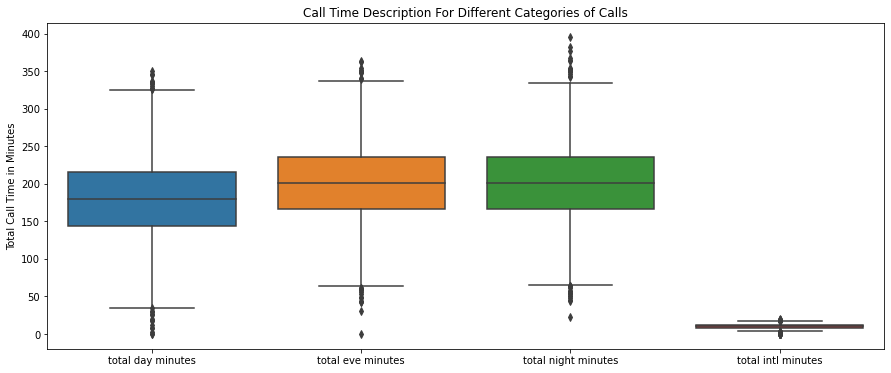

In [9]:
#Understanding the data set
#plot the measures of central tendancies for call length

minutes_columns = ["total day minutes","total eve minutes","total night minutes","total intl minutes"]
# Create the box plot
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_cleaned[minutes_columns])
plt.ylabel("Total Call Time in Minutes")
plt.title("Call Time Description For Different Categories of Calls")
plt.show()


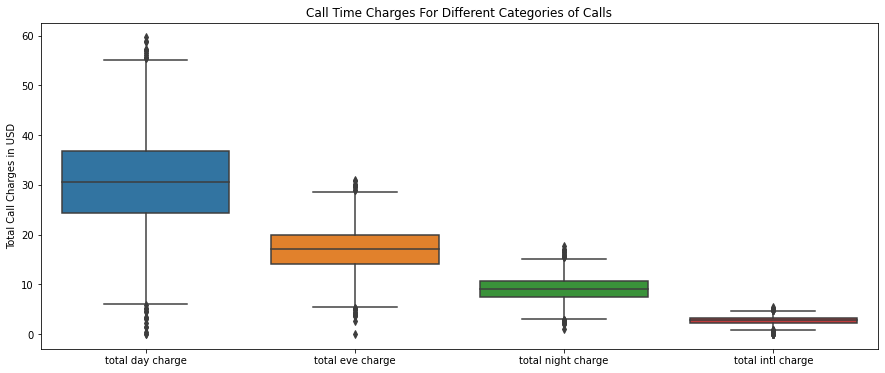

In [10]:
#Understanding the data set
#plot the measures of central tendancies for call charges

charge_columns = ["total day charge","total eve charge","total night charge","total intl charge"]
# Create the box plot
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_cleaned[charge_columns])
plt.ylabel("Total Call Charges in USD")
plt.title("Call Time Charges For Different Categories of Calls")
plt.show()

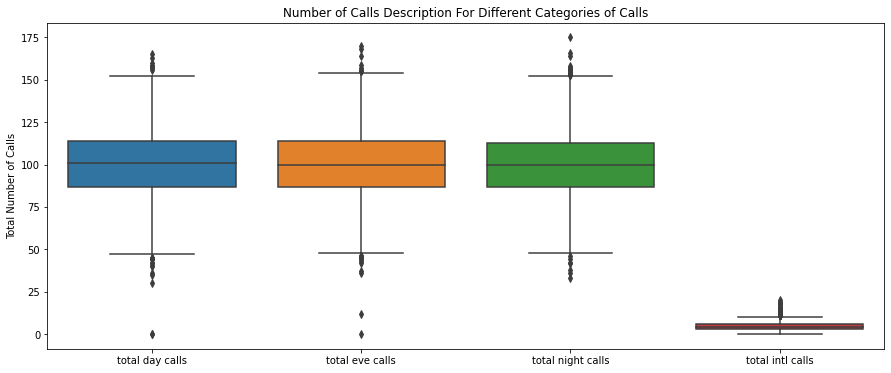

In [11]:
#Understanding the data set
#plot the measures of central tendancies for number of calls

calls_columns = ["total day calls","total eve calls","total night calls","total intl calls"]
# Create the box plot
plt.figure(figsize=(15, 6))
sns.boxplot(data=df_cleaned[calls_columns])
plt.ylabel("Total Number of Calls")
plt.title("Number of Calls Description For Different Categories of Calls")
plt.show()

### Univariate Analysis

In [12]:
#visually check for any relationships between various columns
#sns.pairplot(df_cleaned)

There seems to be 1:1 relationships between call charges and call minutes.

### Bivariate analysis

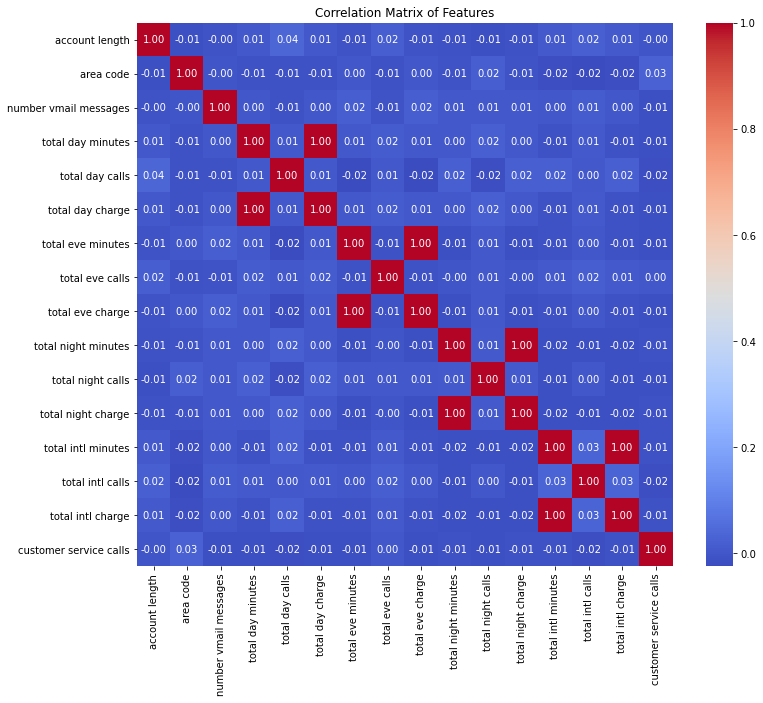

In [13]:
# Calculate the correlation matrix
correlation_matrix = df_cleaned.select_dtypes('number').corr()

# Visualize the heat map
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()


Charges and call-time seem have a perfect correlation. It will be interesting to see how each affects our model individually.

Feature Engineering

In [14]:
# Drop irrelevant columns; Area code, phone number and state are assumed to have no bearing on churn prediction

df_cleaned = df_cleaned.drop(columns=["phone number", "area code", "state"])


#Encode categorical data
df_cleaned["international plan"] = df_cleaned["international plan"].map({"yes": 1, "no": 0})
df_cleaned["voice mail plan"] = df_cleaned["voice mail plan"].map({"yes": 1, "no": 0})
df_cleaned["churn"] = df_cleaned["churn"].astype(int)


In [15]:
# Datasets with different feature selections


#Model 1: The data without any feature engineering
df_baseline = df_cleaned.copy()
df_baseline.head()


#Model 2: The data with feature engineering i.e.
df_engineered = df_cleaned.copy()
df_engineered["total minutes"] = (df_engineered["total day minutes"] + df_engineered["total eve minutes"] + df_engineered["total night minutes"])
df_engineered["total calls"] = (df_engineered["total day calls"] + df_engineered["total eve calls"] + df_engineered["total night calls"])

df_engineered["avg call minutes per day"] = np.where(df_engineered["total calls"] == 0, 0, df_engineered["total minutes"] / df_engineered["total calls"])
df_engineered["avg day call minutes per day"] = np.where(df_engineered["total day calls"] == 0, 0, df_engineered["total day minutes"] / df_engineered["total day calls"])
df_engineered["avg eve call minutes per day"] = np.where(df_engineered["total eve calls"] == 0, 0, df_engineered["total eve minutes"] / df_engineered["total eve calls"])
df_engineered["avg night call minutes per day"] = np.where(df_engineered["total night calls"] == 0, 0, df_engineered["total night minutes"] / df_engineered["total night calls"])
df_engineered["avg intl call minutes per day"] = np.where(df_engineered["total intl calls"] == 0, 0, df_engineered["total intl minutes"] / df_engineered["total intl calls"])

#Number of calls ratios
df_engineered["day call ratio"] = np.where(df_engineered["total calls"] == 0, 0, df_engineered["total day calls"] / df_engineered["total calls"])
df_engineered["eve call ratio"] = np.where(df_engineered["total calls"] == 0, 0, df_engineered["total eve calls"] / df_engineered["total calls"])
df_engineered["night call ratio"] = np.where(df_engineered["total calls"] == 0, 0, df_engineered["total night calls"] / df_engineered["total calls"])
df_engineered["intl call ratio"] = np.where(df_engineered["total calls"] == 0, 0, df_engineered["total intl calls"] / df_engineered["total calls"])
df_engineered["vmail_ratio"] = np.where(df_engineered["total calls"] == 0, 0, df_engineered["number vmail messages"] / df_engineered["total calls"])

#Call duration ratios
df_engineered["day minutes ratio"] = np.where(df_engineered["total minutes"] == 0, 0, df_engineered["total day minutes"] / df_engineered["total minutes"])
df_engineered["eve minutes ratio"] = np.where(df_engineered["total minutes"] == 0, 0, df_engineered["total eve minutes"] / df_engineered["total minutes"])
df_engineered["night minutes ratio"] = np.where(df_engineered["total minutes"] == 0, 0, df_engineered["total night minutes"] / df_engineered["total minutes"])
df_engineered["intl minutes ratio"] = np.where(df_engineered["total minutes"] == 0, 0, df_engineered["total intl minutes"] / df_engineered["total minutes"])

#Customer Service Calls ratios
df_engineered["customer_service_call_intensity"] = np.where(df_engineered["account length"] == 0, 0, df_engineered["customer service calls"] / df_engineered["account length"])
df_engineered["customer_service_calls_ratio"] = np.where(df_engineered["total calls"] == 0, 0, df_engineered["customer service calls"] / df_engineered["total calls"])

#Model 3: Only use the engineered features
df_engineered_only = df_engineered.copy()
#colums_to-drop = ["total day minutes", "total day charge",, "total eve calls", "total eve charge","total night minutes", "total night calls", "total night charge","total intl minutes", "total intl calls", "total intl charge"]
#colums_to-drop = ["total day minutes", "total day calls","total day charge","total evening minutes", "total eve calls", "total eve charge","total night minutes", "total night calls", "total night charge","total intl minutes", "total intl calls", "total intl charge"]
colums_to_drop = ["total day minutes", "total day calls","total day charge","total eve minutes", "total eve calls", "total eve charge","total night minutes", "total night calls", "total night charge","total intl minutes", "total intl calls", "total intl charge"]

df_engineered_only = df_engineered_only.drop(columns=colums_to_drop)

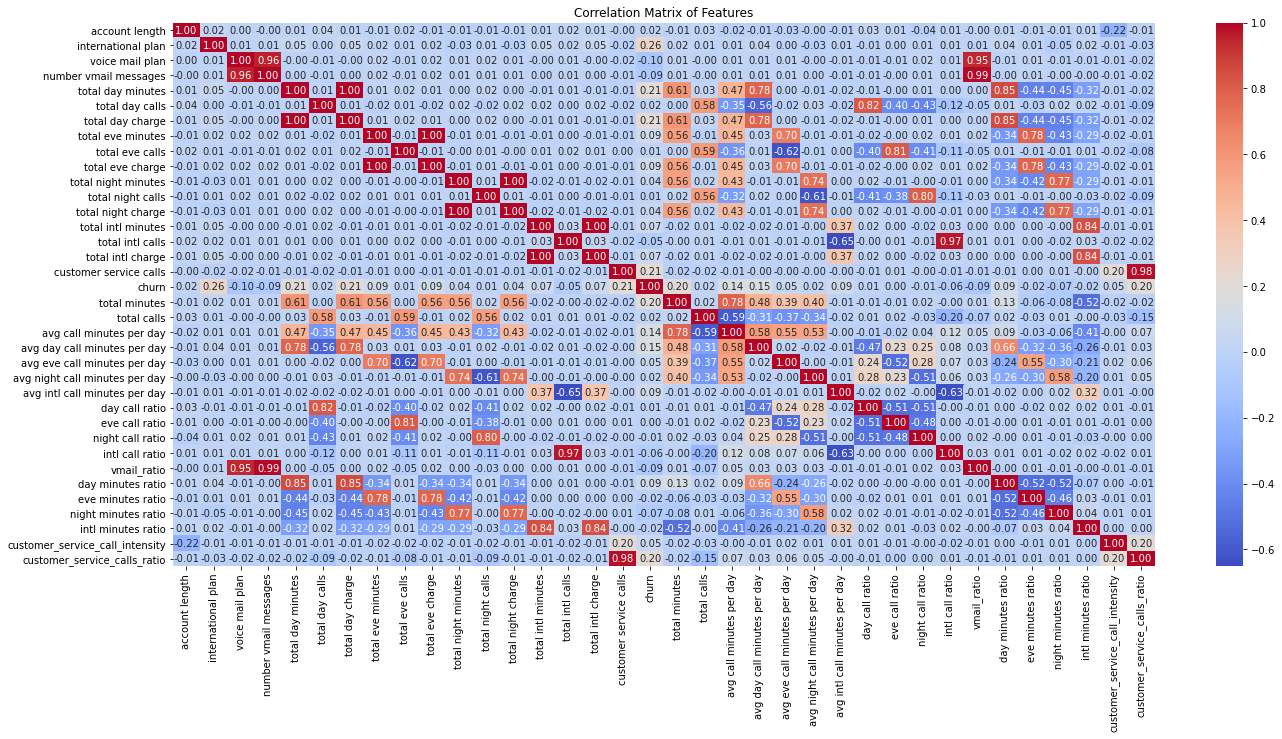

In [16]:
# Calculate the correlation matrix for the newly engineered columns
correlation_matrix = df_engineered.select_dtypes('number').corr()

# Visualize the heat map
plt.figure(figsize=(22, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

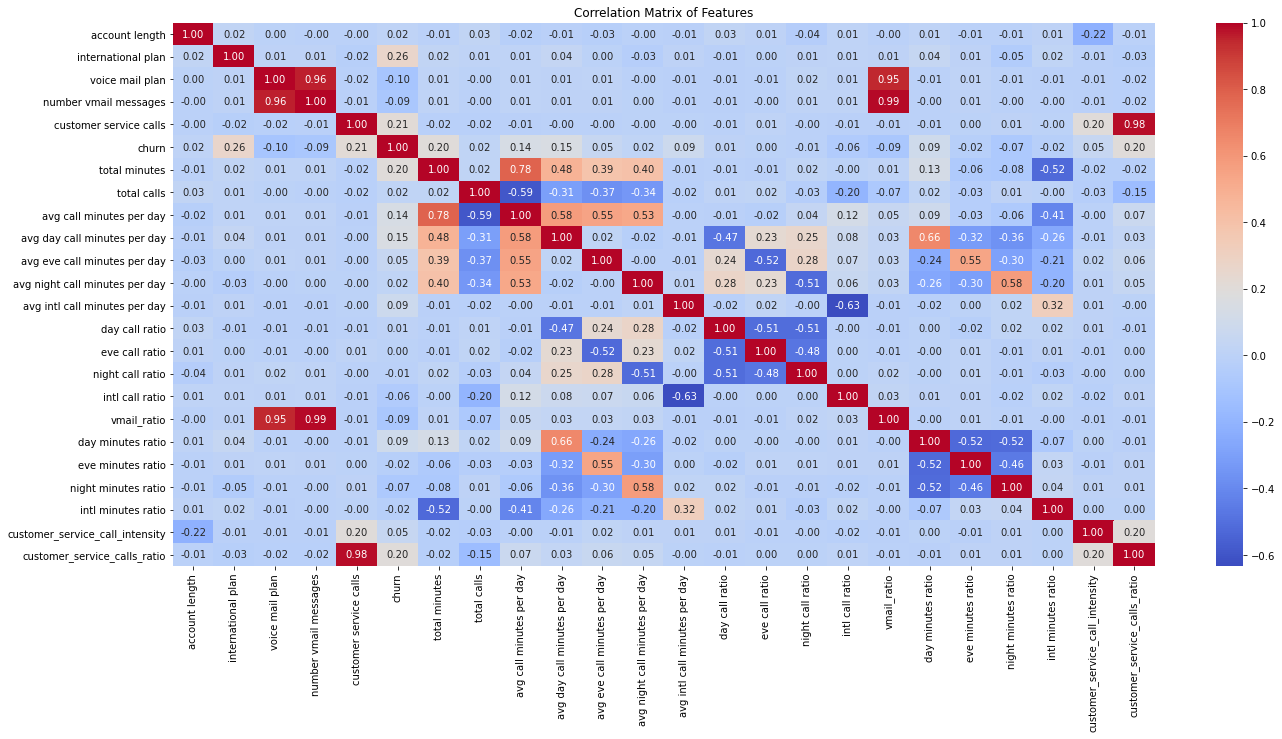

In [17]:
# Calculate the correlation matrix for the newly engineered columns
correlation_matrix = df_engineered_only.select_dtypes('number').corr()

# Visualize the heat map
plt.figure(figsize=(22, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

## Preprocessing

In [18]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   account length          3333 non-null   int64  
 1   international plan      3333 non-null   int64  
 2   voice mail plan         3333 non-null   int64  
 3   number vmail messages   3333 non-null   int64  
 4   total day minutes       3333 non-null   float64
 5   total day calls         3333 non-null   int64  
 6   total day charge        3333 non-null   float64
 7   total eve minutes       3333 non-null   float64
 8   total eve calls         3333 non-null   int64  
 9   total eve charge        3333 non-null   float64
 10  total night minutes     3333 non-null   float64
 11  total night calls       3333 non-null   int64  
 12  total night charge      3333 non-null   float64
 13  total intl minutes      3333 non-null   float64
 14  total intl calls        3333 non-null   

### Encoding

In [19]:
# Convert categorical features
df_cleaned["international plan"] = df_cleaned["international plan"].map({"yes": 1, "no": 0})
df_cleaned["voice mail plan"] = df_cleaned["voice mail plan"].map({"yes": 1, "no": 0})
df_cleaned["churn"] = df_cleaned["churn"].astype(int)

## Modeling - Classification

Using a functional approach, we can check model evaluation performance for various classification techniques to find the most optimal model for predicting churn. Moreover, we can implement different features combinations to find the optimal features that best predict churn.

In [23]:
# Function to train and evaluate models
#the function takes the kind of model, the train and test data, and a label to identify the iteration in the results
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test, description):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return [description, accuracy_score(y_test, y_pred), precision_score(y_test, y_pred), recall_score(y_test, y_pred), f1_score(y_test, y_pred), roc_auc_score(y_test, y_pred)]


# Define datasets for iterations
#df_baseline is the cleaned data with no imputed columns i.e. all the original columns are used as features
#df_engineered is the cleaned data with all imputed columns i.e. all the original columns and engineered columns are used as features
#df_engineered_only is the cleaned data with all imputed columns, but with some of the original columns removed

datasets = {
    "Baseline": df_baseline,
    "Engineered": df_engineered,
    "Engineered Only": df_engineered_only
    }

# Initialize models and state which initialization parameters are to be used.
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=500),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10),
    "Ridge Regression": RidgeClassifier(alpha=1.0, random_state=42),
    "Stochastic Gradient Descent": SGDClassifier(loss='log', penalty='l2', random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "K Nearest Neighbour":KNeighborsClassifier(n_neighbors=3),
    "Support Vector Machine": SVC(random_state=42),
    "AdaBoost Regression": AdaBoostClassifier(n_estimators=100, random_state=42)

}

# Train models for each iteration
structured_results = []
for iteration, df in datasets.items():
    X = df.drop(columns=["churn"])
    y = df["churn"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    for model_name, model in models.items():
        structured_results.append(train_and_evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, f"{iteration} - {model_name}"))

# Convert results to DataFrame
results_df = pd.DataFrame(structured_results, columns=["Model Iteration", "Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"])

# Save results as CSV or display
results_df.to_csv("model_performance_new.csv", index=False)  # Saves results to a CSV file
print(results_df)

                                  Model Iteration  Accuracy  Precision  \
0                  Baseline - Logistic Regression  0.859070   0.533333   
1                        Baseline - Random Forest  0.941529   0.902778   
2                     Baseline - Ridge Regression  0.860570   0.600000   
3          Baseline - Stochastic Gradient Descent  0.850075   0.384615   
4                        Baseline - Decision Tree  0.905547   0.693182   
5                  Baseline - K Nearest Neighbour  0.886057   0.690909   
6               Baseline - Support Vector Machine  0.908546   0.846154   
7                  Baseline - AdaBoost Regression  0.871064   0.577465   
8                Engineered - Logistic Regression  0.863568   0.557692   
9                      Engineered - Random Forest  0.932534   0.933333   
10                  Engineered - Ridge Regression  0.872564   0.730769   
11       Engineered - Stochastic Gradient Descent  0.841079   0.333333   
12                     Engineered - De

From the results, Random Forest ranks in the top 3 for accuracy.

<figure>
    <img src="pictures/accuracy.png" alt="Description" width="1000">
    <figcaption>The Machine Learning Process</figcaption>
</figure>

Random Forest ranks in the top 3 for precision

<figure>
    <img src="pictures/precision.png" alt="Description" width="1000">
    <figcaption>The Machine Learning Process</figcaption>
</figure>

Recall is highest in the "Engineered Only" feature selection for a Decision Tree model. However, the Baseline Radom Forest model is a close second

<figure>
    <img src="pictures/recall.png" alt="Description" width="1000">
    <figcaption>The Machine Learning Process</figcaption>
</figure>

The Baseline Random Forest model yields the highest F_1 score.

<figure>
    <img src="pictures/fi_score.png" alt="Description" width="1000">
    <figcaption>The Machine Learning Process</figcaption>
</figure>

The Baseline Random Forest Model yields the highest AUC_ROC score.

<figure>
    <img src="pictures/auc_roc.png" alt="Description" width="1000">
    <figcaption>The Machine Learning Process</figcaption>
</figure>

It is evident that the Random Forest Technique yields the best performance across the board. We can therefore proceed with Random Forest Classification going forward.

#### Random Forest

Accuracy: 0.9430284857571214
Recall: 0.6804123711340206
Precision: 0.9041095890410958
F1-score: 0.7764705882352942
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       570
           1       0.90      0.68      0.78        97

    accuracy                           0.94       667
   macro avg       0.93      0.83      0.87       667
weighted avg       0.94      0.94      0.94       667



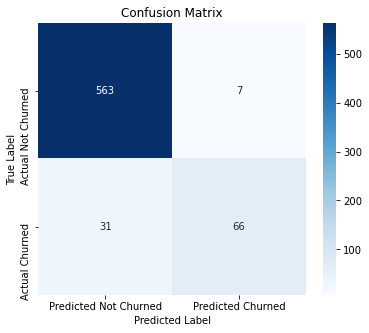

In [24]:
# Initialize and train the random forest classifier
rf_model = RandomForestClassifier(random_state=42)  

df_final_ML = df_baseline.copy()

X = df_final_ML.drop(columns=["churn"])
y = df_final_ML["churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"F1-score: {f1}")

# Classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted Not Churned', 'Predicted Churned'],
            yticklabels=['Actual Not Churned', 'Actual Churned'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


We therefore decide to use Random Forest Models and apply more effort in the feature selection to enhance performance. For a start, we randomly select 5 features 100 times and evaluate the performance of the Random Forest Model each time. This will help us determine if their is an optimal combination of features that can enhance the prediction metrics further. With more computing power, we can increase the number of combination simulations.

In [ ]:
# Randomly select 10 features and evaluate performance of a random forest model using these features

# Dont rerun this, it took 2 hours to complete

num_iterations = 10000
np.random.seed(42)  # For reproducibility
best_performance = {"features": None, "accuracy": 0, "precision": 0, "recall": 0, "f1_score": 0, "auc_roc": 0}

# Store results for all iterations
feature_selection_results = []

for i in range(num_iterations):
    selected_features = np.random.choice(X.columns, 10, replace=False)
    X_selected = X[selected_features]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

    # Train and evaluate Random Forest model
    rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred)

    feature_selection_results.append([i + 1, list(selected_features), accuracy, precision, recall, f1, auc_roc])

    # Check if this is the best-performing model
    if f1 > best_performance["f1_score"]:
        best_performance.update({"features": selected_features, "accuracy": accuracy, "precision": precision, "recall": recall, "f1_score": f1, "auc_roc": auc_roc})

# Convert results to DataFrame
feature_selection_df = pd.DataFrame(feature_selection_results, columns=["Iteration", "Selected Features", "Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"])

# Display results
print(feature_selection_df)
feature_selection_df.to_csv("randomized_feature_seclection.csv")


c:\Users\hp\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\hp\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\hp\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classification.py:1221: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\hp\anaconda3\envs\learn-env\lib\site-packages\sklearn\metrics\_classifica

      Iteration                                  Selected Features  Accuracy  \
0             1  [account length, international plan, total day...  0.892054   
1             2  [total intl calls, total intl charge, total da...  0.889055   
2             3  [customer service calls, international plan, t...  0.910045   
3             4  [total night minutes, total eve minutes, accou...  0.917541   
4             5  [total intl charge, customer service calls, to...  0.896552   
...         ...                                                ...       ...   
9995       9996  [total day calls, total day charge, voice mail...  0.919040   
9996       9997  [customer service calls, total night charge, t...  0.920540   
9997       9998  [total eve minutes, total day charge, customer...  0.911544   
9998       9999  [total night minutes, total day minutes, numbe...  0.904048   
9999      10000  [total eve minutes, total eve charge, number v...  0.928036   

      Precision    Recall  F1 Score   A

In [26]:
print(best_performance)

{'features': array(['total eve minutes', 'total day charge', 'total intl calls',
       'international plan', 'total intl minutes', 'total eve charge',
       'number vmail messages', 'customer service calls',
       'total night minutes', 'voice mail plan'], dtype=object), 'accuracy': 0.952023988005997, 'precision': 0.922077922077922, 'recall': 0.7319587628865979, 'f1_score': 0.8160919540229885, 'auc_roc': 0.8607162235485621}


From random sampling of the features, the following combination yielded the best performance

In [27]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Parameters
num_iterations = 10000  # Adjust based on your dataset size
feature_subset_size = 10  # Number of features per selection
np.random.seed(42)  # For reproducibility

# Track the best model performance
best_performance = {"features": None, "accuracy": 0, "precision": 0, "recall": 0, "f1_score": 0, "auc_roc": 0}

# Store results
feature_selection_results = []
unique_feature_sets = set()

# Define maximum unique feature sets possible
max_possible_combinations = min(num_iterations, len(X.columns) ** feature_subset_size)

# Run iterations
for i in range(max_possible_combinations):
    while True:
        selected_features = tuple(np.random.choice(X.columns, feature_subset_size, replace=False))
        if selected_features not in unique_feature_sets:
            unique_feature_sets.add(selected_features)
            break  # Ensure we only store unique selections

    X_selected = X[list(selected_features)]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42, stratify=y)

    # Train and evaluate Random Forest model
    rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10)
    rf_model.fit(X_train, y_train)
    y_pred = rf_model.predict(X_test)

    # Evaluate performance
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=1)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_roc = roc_auc_score(y_test, y_pred)

    feature_selection_results.append([i + 1, list(selected_features), accuracy, precision, recall, f1, auc_roc])

    # Check if this is the best-performing model
    if f1 > best_performance["f1_score"]:
        best_performance.update({
            "features": selected_features,
            "accuracy": accuracy,
            "precision": precision,
            "recall": recall,
            "f1_score": f1,
            "auc_roc": auc_roc
        })

# Convert results to DataFrame
feature_selection_df = pd.DataFrame(feature_selection_results, columns=["Iteration", "Selected Features", "Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"])

# Save results
feature_selection_df.to_csv("optimized_random_feature_selection.csv", index=False)
print(feature_selection_df)

      Iteration                                  Selected Features  Accuracy  \
0             1  [account length, international plan, total day...  0.892054   
1             2  [total intl calls, total intl charge, total da...  0.889055   
2             3  [customer service calls, international plan, t...  0.910045   
3             4  [total night minutes, total eve minutes, accou...  0.917541   
4             5  [total intl charge, customer service calls, to...  0.896552   
...         ...                                                ...       ...   
9995       9996  [total day calls, total day charge, voice mail...  0.919040   
9996       9997  [customer service calls, total night charge, t...  0.920540   
9997       9998  [total eve minutes, total day charge, customer...  0.911544   
9998       9999  [total night minutes, total day minutes, numbe...  0.904048   
9999      10000  [total eve minutes, total eve charge, number v...  0.928036   

      Precision    Recall  F1 Score   A

In [28]:
print(best_performance)

{'features': ('total eve minutes', 'total day charge', 'total intl calls', 'international plan', 'total intl minutes', 'total eve charge', 'number vmail messages', 'customer service calls', 'total night minutes', 'voice mail plan'), 'accuracy': 0.952023988005997, 'precision': 0.922077922077922, 'recall': 0.7319587628865979, 'f1_score': 0.8160919540229885, 'auc_roc': 0.8607162235485621}


Accuracy: 0.9475262368815592
Recall: 0.711340206185567
Precision: 0.9078947368421053
F1-score: 0.7976878612716762
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       570
           1       0.91      0.71      0.80        97

    accuracy                           0.95       667
   macro avg       0.93      0.85      0.88       667
weighted avg       0.95      0.95      0.94       667



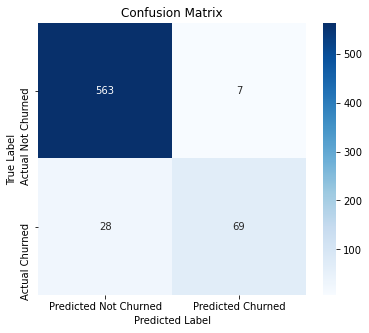

In [30]:
# Initialize and train the random forest classifier
rf_model = RandomForestClassifier(random_state=42)  # You can adjust hyperparameters here

df_final_ML = df_baseline.copy()

X = df_final_ML[['total eve minutes', 'total day charge', 'total intl calls', 'international plan', 'total intl minutes', 'total eve charge', 'number vmail messages', 'customer service calls', 'total night minutes', 'voice mail plan']]
y = df_final_ML["churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"F1-score: {f1}")

# Classification report
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted Not Churned', 'Predicted Churned'],
            yticklabels=['Actual Not Churned', 'Actual Churned'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Insert table showing the iterations

From the observed iterations, there is no combination of randomly selected features that appears to exceed the baseline model that had been generated using all the features. We can elect to proceed with that for now and perform some hyperparameter tuning

### Hyperparameter Tuning

Fitting 5 folds for each of 324 candidates, totalling 1620 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:   14.3s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:  1.1min
[Parallel(n_jobs=-1)]: Done 349 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done 632 tasks      | elapsed:  4.5min
[Parallel(n_jobs=-1)]: Done 997 tasks      | elapsed:  7.1min
[Parallel(n_jobs=-1)]: Done 1442 tasks      | elapsed: 10.3min
[Parallel(n_jobs=-1)]: Done 1620 out of 1620 | elapsed: 11.5min finished


Tuned Random Forest - Accuracy: 0.8860569715142429
Tuned Random Forest - Recall: 0.7216494845360825
Tuned Random Forest - Precision: 0.9178082191780822
Tuned Random Forest - F1-score: 0.7882352941176471
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       570
           1       0.92      0.69      0.79        97

    accuracy                           0.95       667
   macro avg       0.93      0.84      0.88       667
weighted avg       0.94      0.95      0.94       667



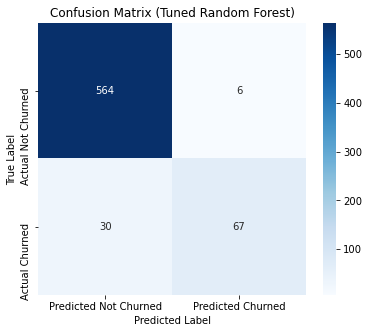

In [40]:
# prompt: tune the random forest model using randomised or gridsearch cv. and refit the rf_model_tuned and metrics as above also

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# prompt: tune the random forest model using randomised or gridsearch cv. and refit the rf_model_tuned and metrics as above also

from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, 30 , 50],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['auto', 'sqrt', 'log2']

}

rf_model = RandomForestClassifier(random_state=42)  # You can adjust hyperparameters here

df_final_ML = df_baseline.copy()

X = df_final_ML[['total eve minutes', 'total day charge', 'total intl calls', 'international plan', 'total intl minutes', 'total eve charge', 'number vmail messages', 'customer service calls', 'total night minutes', 'voice mail plan']]
y = df_final_ML["churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize RandomizedSearchCV or GridSearchCV
# rf_random = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid, n_iter=10, cv=5, verbose=2, random_state=42, n_jobs=-1)
rf_grid = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=5, verbose=2, n_jobs=-1)

# Fit the randomized search to the data
# rf_random.fit(X_train, y_train)
rf_grid.fit(X_train, y_train)


# Get the best estimator from the search
rf_model_tuned = rf_grid.best_estimator_ #or rf_random.best_estimator_

# Make predictions using the tuned model
y_pred = rf_model_tuned.predict(X_test)

# Evaluate the tuned model
rf_accuracy = accuracy_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Tuned Random Forest - Accuracy: {accuracy}")
print(f"Tuned Random Forest - Recall: {recall}")
print(f"Tuned Random Forest - Precision: {precision}")
print(f"Tuned Random Forest - F1-score: {f1}")

print(classification_report(y_test, y_pred))

# Plot confusion matrix for the tuned model
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted Not Churned', 'Predicted Churned'],
            yticklabels=['Actual Not Churned', 'Actual Churned'])
plt.title("Confusion Matrix (Tuned Random Forest)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Accuracy: 0.9385
Recall: 0.7423
Precision: 0.8182
F1-score: 0.7784

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       570
           1       0.82      0.74      0.78        97

    accuracy                           0.94       667
   macro avg       0.89      0.86      0.87       667
weighted avg       0.94      0.94      0.94       667



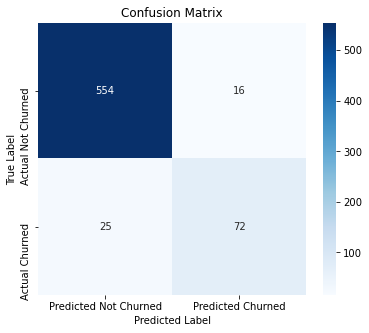

In [35]:
# Initialize and train the random forest classifier but now using class weighting

# Define features and target
X = df_final_ML[['total eve minutes', 'total day charge', 'total intl calls', 'international plan', 'total intl minutes', 'total eve charge', 'number vmail messages', 'customer service calls', 'total night minutes', 'voice mail plan']]
y = df_final_ML["churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardization (if needed for other models, not necessary for Random Forest)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the Random Forest classifier with class weighting
rf_model = RandomForestClassifier(random_state=42, class_weight="balanced", n_estimators=100, max_depth=10)  # Adjust hyperparameters if needed
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-score: {f1:.4f}")

# Print classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Predicted Not Churned', 'Predicted Churned'],
            yticklabels=['Actual Not Churned', 'Actual Churned'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


Even with class weighting, the results do not seem to improve.

## Model evaluation

From these findings, it is evident that the Random Forest Technique yields the best performance across the board. We can therefore proceed with Random Forest Classification going forward.

For the Baseline Random Forest Model, the performance metrics are as follows:

* **Accuracy**: 0.9430284857571214
* **Recall**: 0.6804123711340206
* **Precision**: 0.9041095890410958
* **F1-score**: 0.7764705882352941

We therefore decide apply more effort in the Baseline feature selection to enhance performance. For a start, we randomly select 10 features 100 times and evaluate the performance of the Random Forest Model each time. This will help us determine if their is an optimal combination of features that can enhance the prediction metrics further. With more computing power, we can increase the number of combination simulations.

The following feature combination yielded the best performance metrics (i.e. top in Accuracy, Recall, F1_Score and AUC-ROC SCore):

X = ['total night charge', 'total intl charge', 'voice mail plan', 'total eve minutes', 'total eve charge', 'total day charge', 'total night calls', 'total intl calls', 'customer service calls', 'international plan']

The performance metrics improved to:

* **Accuracy**: 0.950525
* **Recall**: 0.711340
* **Precision**: 0.932432
* **F1-score**: 0.807018

    
# **Recommendation**

* The recall is still a bit low. Other classification techniques e.g. XGBoost Classification could be attempted to yield better model performance.
* More descriptive features could improve model performance e.g. **Customer Service Calls Reasons** or **Subscription Tariff**
* Other ML techniques like SMOTE can be used to handle the data imbalance and subsequently enhance recall